In [ ]:
#Classification Example on the MNIST Dataset

In [ ]:
import sys

assert sys.version_info >= (3, 7)
     

from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
     

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [ ]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)
     

In [ ]:
#I den här delen sätter vi upp miljön. Vi kontrollerar Python- och sklearn-version, 
#importerar bibliotek för visualisering och machine learning, 
#och skapar en mapp för att spara bilder. Vi definierar också en funktion för att enkelt spara grafer.

In [ ]:
#Task 1: Fetch the MNIST dataset

In [ ]:
#Import Necessary Libraries

In [ ]:
import numpy as np  # Library for numerical operations and working with arrays
import matplotlib.pyplot as plt  # Library for creating static, animated, and interactive visualizations

from sklearn.model_selection import train_test_split  # Function to split datasets into training and testing sets
from sklearn.preprocessing import StandardScaler  # Scaler for standardizing features by removing the mean and scaling to unit variance
from sklearn.model_selection import cross_val_score  # Function to evaluate a model using cross-validation
from sklearn.model_selection import GridSearchCV  # Function to perform an exhaustive search over specified parameter values for an estimator

from sklearn.datasets import fetch_openml  # Function to fetch datasets from OpenML, such as the MNIST dataset
from sklearn.linear_model import SGDClassifier  # Stochastic Gradient Descent classifier for training linear models
from sklearn.metrics import confusion_matrix, accuracy_score  # Functions to compute evaluation metrics for classification models

In [ ]:
#Här importerar vi alla nödvändiga bibliotek. 
#NumPy används för datahantering, Matplotlib för visualisering, och scikit-learn för att dela data, 
#träna modeller, göra cross-validation och utvärdera resultat.

In [7]:
#Load the MNIST Dataset

In [10]:
!pip install tensorflow

   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 3.1/350.8 MB 16.8 MB/s eta 0:00:21
    --------------------------------------- 5.8/350.8 MB 14.7 MB/s eta 0:00:24
   - -------------------------------------- 9.4/350.8 MB 15.9 MB/s eta 0:00:22
   - -------------------------------------- 13.4/350.8 MB 16.8 MB/s eta 0:00:21
   -- ------------------------------------- 17.6/350.8 MB 17.6 MB/s eta 0:00:19
   -- ------------------------------------- 22.3/350.8 MB 18.5 MB/s eta 0:00:18
   --- ------------------------------------ 27.0/350.8 MB 19.0 MB/s eta 0:00:18
   --- ------------------------------------ 30.9/350.8 MB 19.1 MB/s eta 0:00:17
   --- ------------------------------------ 34.1/350.8 MB 18.8 MB/s eta 0:00:17
   ---- ----------------------------------- 37.5/350.8 MB 18.6 MB/s eta 0:00:17
   ---- ----------------------------------- 38.5/350.8 MB 17.6 MB/s eta 0:00:18
   ---- ----------------------------------- 39.8/350

In [39]:
import numpy as np
import keras
from keras.datasets import mnist as keras_mnist
#Här laddar vi MNIST-datasetet med Keras istället för OpenML because its more stable and works immediately. 

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras_mnist.load_data()

X = np.concatenate((X_train_raw, X_test_raw), axis=0).reshape(-1, 28 * 28)
y = np.concatenate((y_train_raw, y_test_raw), axis=0).astype(str)
#concatenate= merge train (labels) 
#astype(str) =gör om till text(t.ex: "5" instead of 5)
#reshape= gör om varje bild från 28x28 till 748 pixelvalues 
#Maskininlärning jobbar med vektorer, inte bilder

class MNISTData:
    def __init__(self, data, target):
        self.data = data
        self.target = target
        self.DESCR = "MNIST dataset loaded via Keras workaround."
    def keys(self):
        return ['data', 'target', 'DESCR']

# Create the object the rest of the lab is looking for
mnist = MNISTData(X, y)

print("Workaround complete. Data loaded successfully!")
     

Workaround complete. Data loaded successfully!


In [12]:
print(mnist.DESCR)

MNIST dataset loaded via Keras workaround.


In [13]:
mnist.keys()  #we only use data and target in this notebook

['data', 'target', 'DESCR']

In [14]:
X, y = mnist.data, mnist.target
X
#sparar bilderna(data)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784), dtype=uint8)

In [40]:
y 
#sparar labels (target) 

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype='<U3')

In [16]:
# Display the shape of the data and labels
print(X.shape, y.shape)

(70000, 784) (70000,)


In [17]:
#Den här delen laddar MNIST, gör om bilderna till 784 pixelvärden, 
#sparar labels i y, och skapar objektet mnist som används senare i labben.

In [18]:
#Visualize the Data

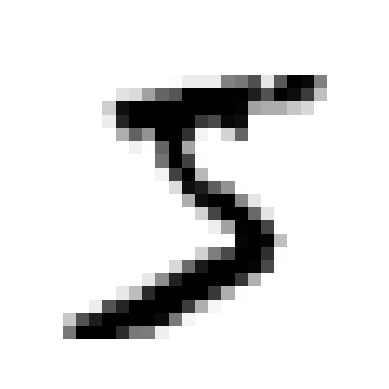

In [42]:
import matplotlib.pyplot as plt


def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary") # to get a grayscale color map where 0 is white and 255 is black
    plt.axis("off")

some_digit = X[0] # display very first didgit in the dataset
plot_digit(some_digit)
#save_fig("some_digit_plot")  # extra code
plt.show()
#we print the label for the image to verify what number it is.

The first digit in the Data set is:  5


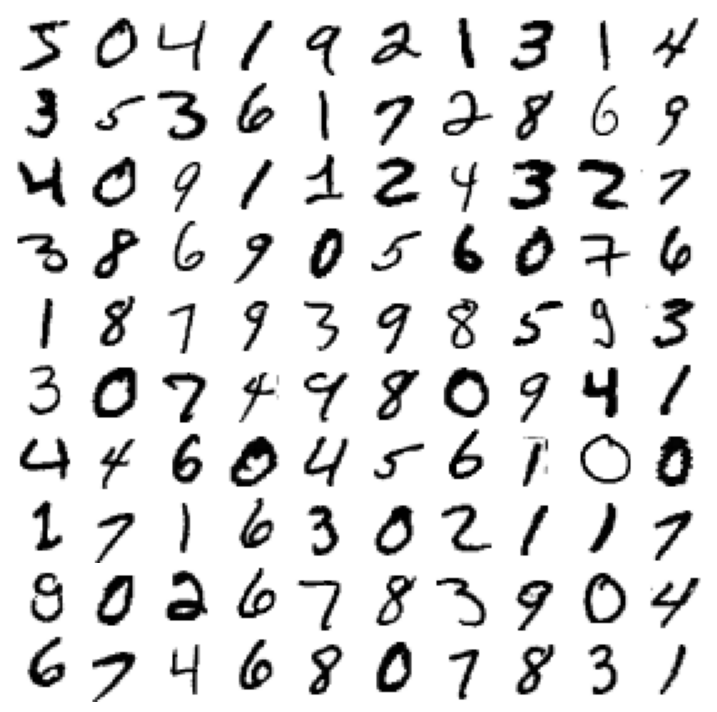

In [43]:
print("The first digit in the Data set is: ", y[0]) # check in the label dataset
     

# This cell generates and saves Figure 3–2
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
#save_fig("more_digits_plot", tight_layout=False)
plt.show()
#we print the label for the image to verify what number it is.

In [23]:
#Split the Data into Training and Test Sets

In [44]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
     

y_train_5 = (y_train == '5')  # True for all 5s, False for all other digits
y_test_5 = (y_test == '5')

In [45]:
#Här delar vi upp datan i träningsdata och testdata. 
#De första 60 000 används för träning och de sista 10 000 för test. 
#Sedan gör vi om problemet till en binär klassificering där vi bara kollar om siffran är en 5 eller inte.

In [46]:
#Training a Binary Classifier

In [47]:
#Stochastic Gradient Descent (SGD) Classifier

In [122]:
# Import the SGDClassifier from Scikit-Learn's linear model module
from sklearn.linear_model import SGDClassifier

# Create an instance of the SGDClassifier with a specified random state for reproducibility
# The random state ensures that the results are consistent across different runs
sgd_clf = SGDClassifier(random_state=42)


# Fit the SGDClassifier to the training data
# 'X_train' is the feature matrix of the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
sgd_clf.fit(X_train, y_train_5)
#Learning rate, regularization (alpha) and number of iterations are most important because they affect how the model learns and performs.

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [49]:
#random_state=42 makes the result the same every time we run the code.
#X_train = bilderna/pixelvärdena
#y_train_5 = labels som säger True om siffran är 5, annars False
#The model thus learns to recognize the number 5 

In [50]:
# following code is to use the trained SGD classifier to make a prediction on a single example, "some_digit".

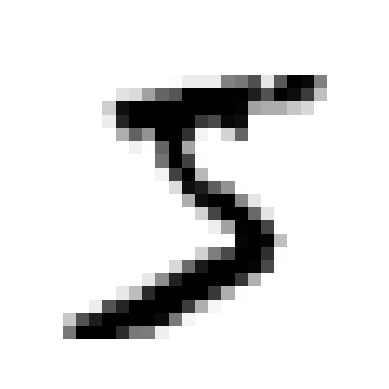

In [51]:
some_digit = X[0] # display very first didgit in the dataset
plot_digit(some_digit)
#save_fig("some_digit_plot")
plt.show()

In [52]:
#X[0]= takes the first image
#plot_digit = shows the image
#save_fig = saves the image 
#plt.show() = dvisar bilden i notebooken

In [53]:
sgd_clf.predict([some_digit])

array([ True])

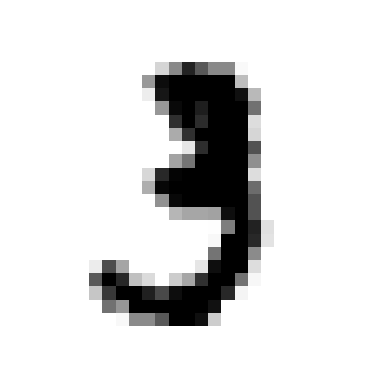

In [54]:
some_digit = X[10] # display 10th didgit in the dataset
plot_digit(some_digit)
#save_fig("some_digit_plot")
plt.show()

In [55]:
sgd_clf.predict([some_digit])

array([False])

In [56]:
# Examples of digits from the dataset
some_digits = X[:5]

# Make predictions on the multiple examples
predictions = sgd_clf.predict(some_digits)

# Display the predictions
print("Predictions for some_digits:", predictions)

Predictions for some_digits: [ True False False False False]


In [57]:
#X[:5]= betyder de 5 första bilderna 

In [58]:
#Measuring Accuracy Using Cross-Validation

In [66]:
from sklearn.model_selection import cross_val_score # Import the cross_val_score function from Scikit-Learn


# Perform 3-fold cross-validation on the SGD classifier
# 'sgd_clf' is the trained SGD classifier
# 'X_train' is the feature matrix of the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
# 'cv=3' specifies 3-fold cross-validation
# 'scoring="accuracy"' specifies that we want to calculate the accuracy score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

# Display the cross-validation accuracy scores
#print("Cross-validation accuracy:", cross_val_score)

array([0.95035, 0.96035, 0.9604 ])

In [ ]:
#Split the data into 3 parts. 
#Trains the models 3 times, and test on different parts each time.
#Because its provieds more reliable results than just a train/test split.

In [60]:
#Implementing Cross-Validation

In [69]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3) # add shuffle=True if the dataset is not
#Skapar 3-fold cross-validation      # already shuffled

for train_index, test_index in skfolds.split(X_train, y_train_5):
    #delar upp data i train/test 
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    #tränar modellen 
    y_pred = clone_clf.predict(X_test_fold)
    #let the model guess whether tha image is a 5 or not.  
    n_correct = sum(y_pred == y_test_fold)
    #how many will get right
    print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


In [62]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train))) # it prints False: which means no 5s detected

False


In [78]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")
#Test the dummy model several times to see how many correct answers it gets.
#We use cross-validation for better evaluation and compare with a dummy model to show that accuracy can be misleading.

array([0.90965, 0.90965, 0.90965])

In [77]:
#Confusion Matrix

In [71]:
# Import cross_val_predict function from Scikit-Learn
from sklearn.model_selection import cross_val_predict

# Generate cross-validated predictions for the training set
# 'sgd_clf' is the trained SGD classifier
# 'X_train' is the feature matrix of the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
# 'cv=3' specifies 3-fold cross-validation
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
     

In [72]:
# Import confusion_matrix function from Scikit-Learn
from sklearn.metrics impxort confusion_matrix

# Compute the confusion matrix to evaluate the classifier's performance
# 'y_train_5' are the actual labels (riktigt svar)
# 'y_train_pred' are the predicted labels from cross-validation ( modell gissning 
cm = confusion_matrix(y_train_5, y_train_pred)
#cm

In [73]:
# Display the confusion matrix
print(cm)

[[53892   687]
 [ 1891  3530]]


In [74]:
# Pretend we reached perfection by setting the predicted labels equal to the true labels
y_train_perfect_predictions = y_train_5

# Compute the confusion matrix with perfect predictions
# The confusion matrix should show all true positives and true negatives, with no false positives or false negatives
confusion_matrix(y_train_5, y_train_perfect_predictions)
#Confusion matrix visar hur många rätt och fel modellen gör i varje kategori

array([[54579,     0],
       [    0,  5421]])

In [79]:
#Precision and Recall

In [123]:
# Import precision_score and recall_score from Scikit-Learn
from sklearn.metrics import precision_score, recall_score


# Compute the precision score
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_train_pred' are the predicted labels from the classifier
precision = precision_score(y_train_5, y_train_pred)  # # Calculate precision: TP / (FP + TP) that is == 3530 / (687 + 3530)
print("Precision:", precision)
#Hur många av de som modellen sa var 5 är faktiskt 5
#84% av gångerna modellen säger "5" är det rätt 

Precision: 0.8370879772350012


In [81]:
#To compute the precision manually using the confusion matrix
# 'cm[1, 1]' is TP, 'cm[0, 1]' is FP
precision_manual = cm[1, 1] / (cm[0, 1] + cm[1, 1])
print("Manual precision calculation:", precision_manual) # manual precision calucltion from the confusion matrix

Manual precision calculation: 0.8370879772350012


In [82]:
# Compute the recall score
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_train_pred' are the predicted labels from the classifier
recall = recall_score(y_train_5, y_train_pred)  # Calculate recall: TP / (FN + TP)
print("Recall:", recall)
#Hur många av alla riktiga 5:or hittar modellen
#modellen hittar vara 65% av alla 5:or.

Recall: 0.6511713705958311


In [83]:
# To compute the recall manually using the confusion matrix
# 'cm[1, 1]' is TP, 'cm[1, 0]' is FN
recall_manual = cm[1, 1] / (cm[1, 0] + cm[1, 1])
print("Manual recall calculation:", recall_manual) # manual recall calucltion from the confusion matrix

Manual recall calculation: 0.6511713705958311


In [ ]:
#Precision = hur rätt modellen är, 
#Recall = hur mycket den hittar

In [84]:
#F1 Score:

In [85]:

# Import the f1_score function from Scikit-Learn
from sklearn.metrics import f1_score

# Compute the F1 Score
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_train_pred' are the predicted labels from the classifier
f1 = f1_score(y_train_5, y_train_pred)  # Calculate the F1 Score using the precision and recall
print("F1 Score:", f1)
#Modellen är ganska balanserad, men inte perfekt, den är inte perfekt eftersom den missar många 5:or 

F1 Score: 0.7325171197343847


In [86]:
# To compute the F1 Score manually using the confusion matrix
# 'cm[1, 1]' is TP, 'cm[1, 0]' is FN, 'cm[0, 1]' is FP
# extra code – this cell also computes the f1 score
f1_manual = cm[1, 1] / (cm[1, 1] + (cm[1, 0] + cm[0, 1]) / 2)
print("Manual F1 Score calculation:", f1_manual)
     

Manual F1 Score calculation: 0.7325171197343847


In [87]:
from sklearn.metrics import classification_report

# Confusion Matrix
print("Confusion Matrix:")
print(cm)

# Classification Report
class_report = classification_report(y_train_5, y_train_pred)
print("Classification Report:")
print(class_report)
#F1-score visar balansen mellan precision och recall, och rapporten visar att modellen är bättre på ‘inte 5’ än på ‘5’

Confusion Matrix:
[[53892   687]
 [ 1891  3530]]
Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.99      0.98     54579
        True       0.84      0.65      0.73      5421

    accuracy                           0.96     60000
   macro avg       0.90      0.82      0.85     60000
weighted avg       0.95      0.96      0.95     60000



In [88]:
#Precision/Recall Trade-off

In [138]:
#The purpose of following codes is to demonstrate how changing the decision threshold affects the classifier's predictions.

some_digit = X[0] # check for 1st didgit in the dataset, please feel free to check for other digits as well

# Get the decision scores for a single example
# 'sgd_clf' is the trained SGD classifier
# 'decision_function' returns the distance of the samples to the decision boundary
y_scores = sgd_clf.decision_function([some_digit]) #
print("Decision Scores:", y_scores)

Decision Scores: [2164.22030239]


In [139]:
#Using a Threshold of 0

In [140]:
# Apply a decision threshold of 0
# Predict whether 'some_digit' is a positive class (True) or not (False)
threshold = 0
y_some_digit_pred = (y_scores > threshold)
print("Digit prediction based on Decision Score threshold:", y_some_digit_pred)

Digit prediction based on Decision Score threshold: [ True]


In [141]:
# Shows that y_scores > 0 produces the same result as
#              calling predict()
y_scores > 0

array([ True])

In [142]:
#Using a Threshold of 3000

In [143]:
# Apply a decision threshold of 3000
# Predict whether 'some_digit' is a positive class (True) or not (False)
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [144]:
# Perform cross-validation to obtain the decision scores for each instance in the training set
# 'sgd_clf' is the trained SGD classifier
# 'X_train' is the feature matrix for the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
# 'cv=3' specifies 3-fold cross-validation
# 'method="decision_function"' specifies that we want to get the decision scores instead of class labels
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

# 'y_scores' will contain the decision scores for each instance in the training set
print(y_scores)  # Example output: array([1200.5, -500.2, 800.3, ...])
     

[  1200.93051237 -26883.79202424 -33072.03475406 ...  13272.12718981
  -7258.47203373 -16877.50840447]


In [145]:
#Precision/Recall Trade-off Curve

In [146]:
# Import precision_recall_curve from Scikit-Learn
from sklearn.metrics import precision_recall_curve

# Calculate precision and recall for different threshold values
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_scores' are the decision scores obtained from the classifier
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [147]:
print("Current Threshold is set:", threshold)

Current Threshold is set: 3000


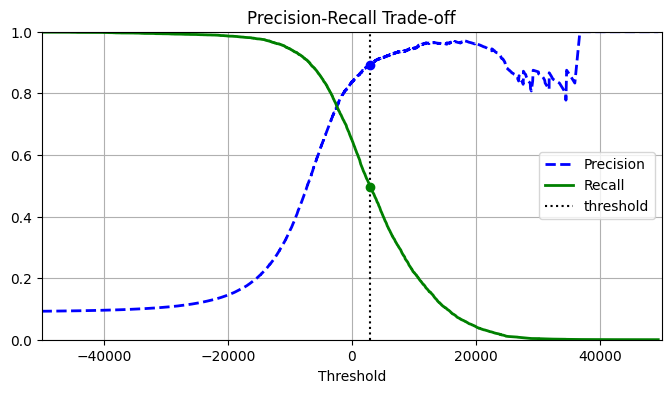

In [148]:
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold # Find the first index where threshold is greater than or equal to the chosen threshold
plt.plot(thresholds[idx], precisions[idx], "bo") # Highlight the precision at the chosen threshold
plt.plot(thresholds[idx], recalls[idx], "go") # Highlight the recall at the chosen threshold
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
plt.title("Precision-Recall Trade-off")
#save_fig("precision_recall_vs_threshold_plot")

plt.show()
     
#As threshold incrases then precision inceases and recall decreases
#Vi kan välja threshold beroende på om vi vill ha hög precision eller hög recall.

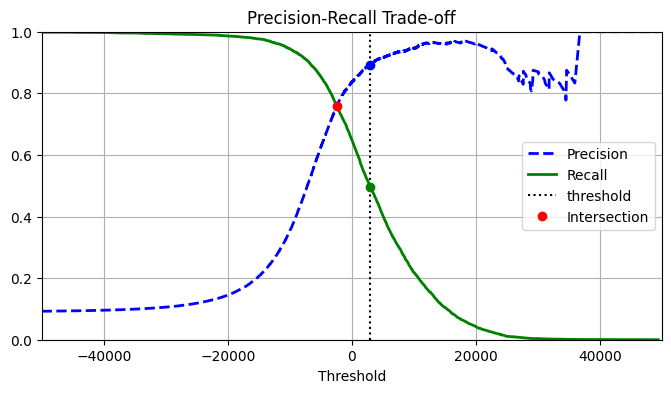

In [149]:
# Highlight the Intersection Point of Precision and Recall


# Find the index where precision and recall are closest to each other
diff = np.abs(precisions - recalls)
min_diff_index = np.argmin(diff)


plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold # Find the first index where threshold is greater than or equal to the chosen threshold
plt.plot(thresholds[idx], precisions[idx], "bo") # Highlight the precision at the chosen threshold
plt.plot(thresholds[idx], recalls[idx], "go") # Highlight the recall at the chosen threshold
plt.plot(thresholds[min_diff_index], precisions[min_diff_index], "ro", label="Intersection") # Highlight the intersection point
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
plt.title("Precision-Recall Trade-off")
#save_fig("precision_recall_vs_threshold_plot")

plt.show()

#That's the limit for when the model says: its 5 or not. 
#precision: increases when threshold increases
#Recall: decreases when threshold increases 
#they cant be prefect: high precision, low recall. 
#Where precision and recall are almost equal a good balance.
#the balck dashed line(threshold): shows which threshold thats had been selected. 
#Grafen visar att när precision går upp, går recall ner.

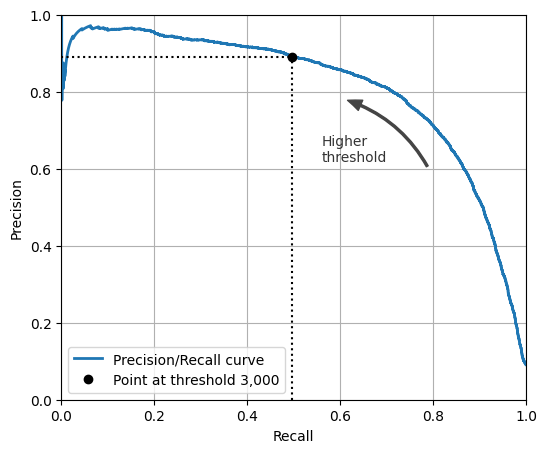

In [150]:
import matplotlib.patches as patches  # For the curved arrow

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# extra code – just beautifies and saves Figure 3–6
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
#save_fig("precision_vs_recall_plot")

plt.show()
#Grafen visar balansen mellan precision och recall. När vi ändrar threshold flyttar vi oss längs kurvan. high threshold= low recall. 

In [151]:
#Suppose you decided to aim for 90% precision. You could use the first plot to find the threshold you need to use, but that is not very precise. 
#Alternatively you search for the lowest threshold that gives you at least 90% precision.

In [152]:
indices_above_90 = np.where(precisions[:len(thresholds)] >= 0.90)[0]

if len(indices_above_90) > 0:
    # Get the first index where precision is >= 0.90
    idx_for_90_precision = indices_above_90[0]
else:
    # If no precision >= 0.90 is found, select the last valid index
    # This is a fallback to prevent IndexError if no threshold meets the criteria
    idx_for_90_precision = len(thresholds) - 1

# Ensure the index is within bounds, especially for edge cases
idx_for_90_precision = min(idx_for_90_precision, len(thresholds) - 1)
idx_for_90_precision = max(idx_for_90_precision, 0)

threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

In [153]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [154]:
precision_score(y_train_5, y_train_pred_90)
     

0.9000345901072293

In [155]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision
     

0.4799852425751706

In [156]:
#The ROC Curve

In [157]:
from sklearn.metrics import roc_curve # Import roc_curve function from Scikit-Learn


# Calculate the ROC curve
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_scores' are the decision scores obtained from the classifier
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)
     

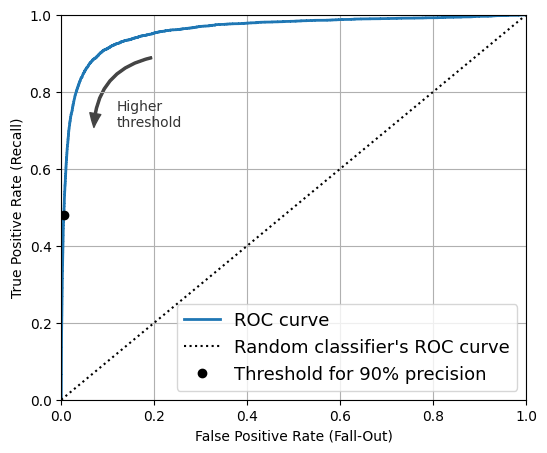

In [158]:
# Find the index of the threshold that gives 90% precision
# 'thresholds' contains the threshold values used to calculate fpr and tpr
# 'threshold_for_90_precision' is a predefined threshold that corresponds to 90% precision
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

# extra code – just beautifies and saves Figure 3–7
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
#save_fig("roc_curve_plot")

plt.show()
#Bästa punkt upp till vänster
#ROC-kurvan visar hur bra modellen är på att hitta rätt utan att göra fel.
#The closer we are to the upper left corner, the better the model, its better because its high recall
#That the model finds many correct answers without making many errors. 

In [159]:
#Area Under the ROC Curve (AUC-ROC)

In [160]:
from sklearn.metrics import roc_auc_score # Import the roc_auc_score function from Scikit-Learn

# Calculate the AUC-ROC score
auc_roc= roc_auc_score(y_train_5, y_scores)

# Display the AUC-ROC score
print("AUC-ROC Score:", auc_roc)

AUC-ROC Score: 0.9604938554008616


In [161]:
#RandomForestClassifier for the same dataset

In [162]:
from sklearn.ensemble import RandomForestClassifier # Import the RandomForestClassifier from Scikit-Learn

# Create an instance of the Random Forest Classifier
forest_clf = RandomForestClassifier(random_state=42)

In [163]:
# Perform cross-validation to obtain probability predictions for each instance in the training set
# 'forest_clf' is the Random Forest classifier
# 'X_train' is the feature matrix of the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
# 'cv=3' specifies 3-fold cross-validation
# 'method="predict_proba"' specifies that we want to get the probability predictions instead of class labels
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

In [164]:
# Display the first two probability predictions
y_probas_forest[:2]
     

array([[0.11, 0.89],
       [0.99, 0.01]])

In [165]:
y_scores_forest = y_probas_forest[:, 1]

# Calculate precision and recall for different threshold values
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_scores_forest' are the scores (probabilities) for the positive class
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest)
#Random Forest ger bättre predictions och sannolikheter istället för bara ja/nej

In [166]:
print("Precision Forest=", precisions_forest)
print("Recall Forest=", recalls_forest)
print("Threshold Forest=", thresholds_forest)

Precision Forest= [0.09035    0.15601796 0.21697018 0.2782198  0.3359375  0.39168474
 0.4434341  0.49221099 0.53883011 0.58103448 0.62384152 0.65814579
 0.69354839 0.72090213 0.74856904 0.77310803 0.79370733 0.81468478
 0.83029737 0.84566529 0.8605178  0.87232994 0.88209825 0.89121268
 0.90208833 0.90986159 0.9178634  0.92464178 0.93120086 0.93672255
 0.94127273 0.94605505 0.95223107 0.95618941 0.95927941 0.96257089
 0.96431961 0.96689629 0.96939365 0.97113522 0.97292032 0.975495
 0.97634069 0.9787572  0.98101519 0.98323571 0.98412375 0.98566455
 0.98719273 0.98773389 0.98974681 0.99050833 0.99129327 0.99186644
 0.99180858 0.99259582 0.99340804 0.99378606 0.99440841 0.99458239
 0.99474526 0.99514451 0.99555659 0.99622997 0.99618594 0.99638031
 0.9965661  0.99652605 0.99672462 0.99692938 0.99688393 0.99762031
 0.9981203  0.99809004 0.99832496 0.99828816 0.99825581 0.99821694
 0.99847793 0.99843309 0.99903038 0.99900498 0.99897119 0.99893692
 0.9989011  0.9996173  1.         1.         1

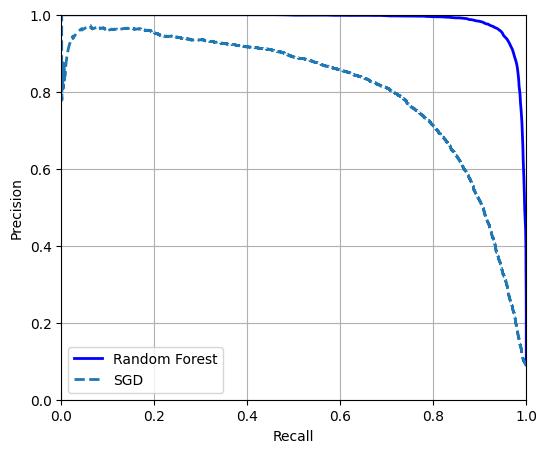

In [167]:
plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

# extra code – just beautifies and saves Figure 3–8
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
#save_fig("pr_curve_comparison_plot")

plt.show()
#the blue line is better than SGD because its closer to the top right corner, so its has better precision and recall. 

In [168]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5  # positive proba ≥ 50%
f1_score(y_train_5, y_train_pred_forest)
     

0.9274509803921569

In [169]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983436731328145

In [170]:
precision_score(y_train_5, y_train_pred_forest)

0.9897468089558485

In [171]:
recall_score(y_train_5, y_train_pred_forest)

0.8725327430363402

In [172]:
#For class report

# Classification Report SGD
#class_report_SGD = classification_report(y_train_5, y_train_pred)
#print("Classification Report of SGD:")
#print(class_report_SGD)


# Classification Report SGD
class_report_forest = classification_report(y_train_5, y_train_pred_forest)
print("Classification Report of Random Fdrest:")
print(class_report_forest)

Classification Report of Random Fdrest:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99     54579
        True       0.99      0.87      0.93      5421

    accuracy                           0.99     60000
   macro avg       0.99      0.94      0.96     60000
weighted avg       0.99      0.99      0.99     60000



In [173]:
#Hög threshold = hög precision, låg recall är bra när fel är dyrt 
#Låg threshold = låg precision, hög recall är bra vi vill inte missa något.
#Om det är viktigt att inte missa positiva fall(case) väljer man hög recall
#Om det är viktigt att vara säker när modellen säger positivt väljer man hög precision

In [176]:
#SGD = Stochastic Gradient Descent
#SGD är en snabb och enkel modell som lär sig linjärt genom att justera sig lite i taget. can only draw a straight line
#misses complex patterns
####
#Random Forest är många träd som tillsammans gör en mer stabil och ofta bättre prediction. and its better because it can learn complex patterns, 
#less risk of making mistakes 
###
#SGD is fast and simple, Random Forest is more complex and usually more accurate.